In [279]:
# ============================================
# 0. 라이브러리 import
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


데이터 크기: (4898, 12)

데이터 정보:
<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         4898 non-null   float64
 1   volatile_acidity      4898 non-null   float64
 2   citric_acid           4898 non-null   float64
 3   residual_sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free_sulfur_dioxide   4898 non-null   float64
 6   total_sulfur_dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


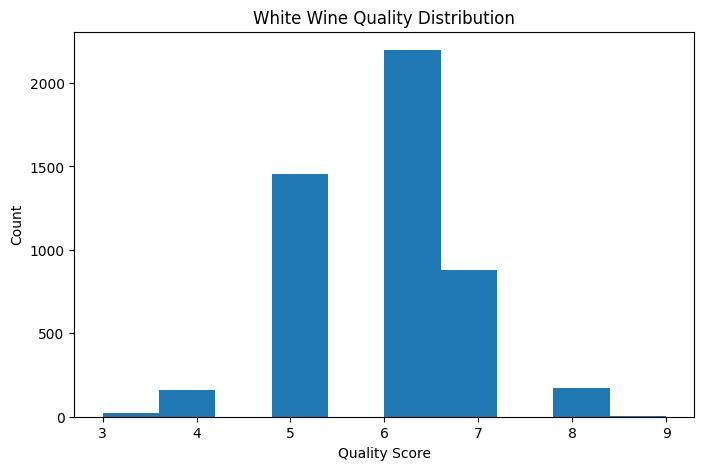

quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


In [280]:
# ============================================
# 1. 화이트 와인 데이터 불러오기
# ============================================
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

whitewines = pd.read_csv(DATA_URL, sep=';')
whitewines.columns = [col.replace(" ", "_") for col in whitewines.columns]

print("데이터 크기:", whitewines.shape)
print("\n데이터 정보:")
whitewines.info()

plt.figure(figsize=(8, 5))
plt.hist(whitewines["quality"], bins=10)
plt.title("White Wine Quality Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

print(whitewines["quality"].value_counts().sort_index())

In [281]:
# ============================================
# 2. 입력(X), 타깃(y) 분리
# ============================================
X = whitewines.drop("quality", axis=1)
y = whitewines["quality"]

print("X columns:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

X columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']
X shape: (4898, 11)
y shape: (4898,)


In [282]:
# ============================================
# 3. random train / test 분리
# - 전체 데이터에서 무작위 분할
# - test는 20%
# ============================================
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("X_train_valid:", X_train_valid.shape)
print("X_test:", X_test.shape)
print("y_train_valid:", y_train_valid.shape)
print("y_test:", y_test.shape)

X_train_valid: (3918, 11)
X_test: (980, 11)
y_train_valid: (3918,)
y_test: (980,)


In [283]:
# ============================================
# 4. random train / valid 분리
# - train_valid 내부에서 valid 20%
# - 최종적으로 전체 기준 train 72%, valid 8%, test 20%
# ============================================
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,
    y_train_valid,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)
print("y_test:", y_test.shape)

X_train: (3526, 11)
X_valid: (392, 11)
X_test: (980, 11)
y_train: (3526,)
y_valid: (392,)
y_test: (980,)


In [284]:
# ============================================
# 5. 스케일링
# - scaler는 train에만 fit
# ============================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print("train mean:", X_train_scaled.mean(axis=0).round(4))
print("train std :", X_train_scaled.std(axis=0).round(4))


train mean: [-0.  0.  0.  0. -0.  0.  0.  0.  0.  0. -0.]
train std : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [285]:
# ============================================
# 6. Tensor 변환
# ============================================
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_valid_tensor:", X_valid_tensor.shape)
print("y_valid_tensor:", y_valid_tensor.shape)
print("X_test_tensor :", X_test_tensor.shape)
print("y_test_tensor :", y_test_tensor.shape)

X_train_tensor: torch.Size([3526, 11])
y_train_tensor: torch.Size([3526, 1])
X_valid_tensor: torch.Size([392, 11])
y_valid_tensor: torch.Size([392, 1])
X_test_tensor : torch.Size([980, 11])
y_test_tensor : torch.Size([980, 1])


In [286]:
# ============================================
# 7. DataLoader
# ============================================
BATCH_SIZE = 16

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("len(train_loader):", len(train_loader))
print("len(valid_loader):", len(valid_loader))
print("len(test_loader):", len(test_loader))

len(train_loader): 221
len(valid_loader): 25
len(test_loader): 62


In [287]:
# ============================================
# 8. 모델 정의
# ============================================
class WineQualityRegressor(nn.Module):
    def __init__(self, input_dim):
        super(WineQualityRegressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)


input_dim = X_train_tensor.shape[1]
model = WineQualityRegressor(input_dim).to(device)
print(model)

WineQualityRegressor(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [288]:
# ============================================
# 9. 손실함수 / 옵티마이저
# ============================================
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

EPOCHS = 200

In [289]:
# ============================================
# 10. Early Stopping 설정
# ============================================
patience = 20
min_delta = 1e-4

best_val_loss = float("inf")
best_model_state = None
early_stop_counter = 0

train_losses = []
valid_losses = []


In [290]:
# ============================================
# 11. 학습 루프 + validation + early stopping
# ============================================
for epoch in range(EPOCHS):

    # train
    model.train()
    train_epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        train_epoch_loss += loss.item() * batch_X.size(0)

    train_epoch_loss /= len(train_loader.dataset)
    train_losses.append(train_epoch_loss)

    # validation
    model.eval()
    valid_epoch_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in valid_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            valid_epoch_loss += loss.item() * batch_X.size(0)

    valid_epoch_loss /= len(valid_loader.dataset)
    valid_losses.append(valid_epoch_loss)

    scheduler.step(valid_epoch_loss)

    # early stopping
    if valid_epoch_loss < best_val_loss - min_delta:
        best_val_loss = valid_epoch_loss
        best_model_state = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d}/{EPOCHS} | "
            f"Train MSE: {train_epoch_loss:.4f} | "
            f"Valid MSE: {valid_epoch_loss:.4f} | "
            f"Patience: {early_stop_counter}/{patience}"
        )

    if early_stop_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

Epoch  10/200 | Train MSE: 0.8441 | Valid MSE: 0.5209 | Patience: 0/20
Epoch  20/200 | Train MSE: 0.7294 | Valid MSE: 0.4249 | Patience: 0/20
Epoch  30/200 | Train MSE: 0.6772 | Valid MSE: 0.4269 | Patience: 5/20
Epoch  40/200 | Train MSE: 0.6593 | Valid MSE: 0.4156 | Patience: 9/20
Epoch  50/200 | Train MSE: 0.6163 | Valid MSE: 0.4065 | Patience: 4/20
Epoch  60/200 | Train MSE: 0.6273 | Valid MSE: 0.4077 | Patience: 6/20
Epoch  70/200 | Train MSE: 0.6070 | Valid MSE: 0.4063 | Patience: 16/20
Epoch  80/200 | Train MSE: 0.6180 | Valid MSE: 0.4051 | Patience: 2/20
Epoch  90/200 | Train MSE: 0.5991 | Valid MSE: 0.4052 | Patience: 12/20

Early stopping at epoch 98


In [291]:
# ============================================
# 12. best model 복원
# ============================================
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Best validation loss restored: {best_val_loss:.4f}")

Best validation loss restored: 0.4035


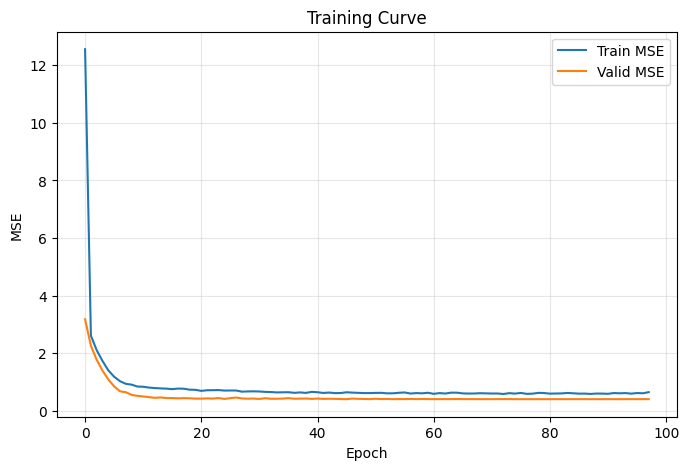

In [292]:
# ============================================
# 13. 학습 곡선 시각화
# ============================================
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train MSE")
plt.plot(valid_losses, label="Valid MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [293]:
# ============================================
# 14. test 예측
# ============================================
model.eval()

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    test_predictions = model(X_test_device)

test_predictions = test_predictions.cpu().numpy().flatten()
actual_values = y_test.values

print("예측값 상위 10개:")
print(test_predictions[:10])

print("\n실제값 상위 10개:")
print(actual_values[:10])

예측값 상위 10개:
[6.0162487 6.9854674 6.4964256 5.7398987 6.535363  6.3262773 5.204643
 5.1291904 5.985739  5.190796 ]

실제값 상위 10개:
[7 8 8 5 7 6 5 4 6 5]


In [294]:
# ============================================
# 15. 예측값 / 실제값 describe
# ============================================
pred_series = pd.Series(test_predictions, name="predicted_quality")
actual_series = pd.Series(actual_values, name="actual_quality")

print("\n[predicted describe]")
print(pred_series.describe())

print("\n[actual describe]")
print(actual_series.describe())


[predicted describe]
count    980.000000
mean       5.879153
std        0.565383
min        2.923105
25%        5.455675
50%        5.871017
75%        6.245311
max        8.080534
Name: predicted_quality, dtype: float64

[actual describe]
count    980.000000
mean       5.904082
std        0.880491
min        3.000000
25%        5.000000
50%        6.000000
75%        6.000000
max        8.000000
Name: actual_quality, dtype: float64


In [295]:
# ============================================
# 16. 평가 지표
# ============================================
correlation, p_value = pearsonr(test_predictions, actual_values)
mae = mean_absolute_error(actual_values, test_predictions)
mse = mean_squared_error(actual_values, test_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(actual_values, test_predictions)

train_mean_quality = y_train.mean()
baseline_predictions = np.full_like(actual_values, fill_value=train_mean_quality, dtype=np.float32)
baseline_mae = mean_absolute_error(actual_values, baseline_predictions)

print(f"\nPyTorch correlation: {correlation:.4f}")
print(f"PyTorch MAE: {mae:.4f}")
print(f"PyTorch MSE: {mse:.4f}")
print(f"PyTorch RMSE: {rmse:.4f}")
print(f"PyTorch R2: {r2:.4f}")
print(f"Train mean quality: {train_mean_quality:.4f}")
print(f"Baseline MAE: {baseline_mae:.4f}")


PyTorch correlation: 0.6228
PyTorch MAE: 0.5349
PyTorch MSE: 0.4749
PyTorch RMSE: 0.6892
PyTorch R2: 0.3867
Train mean quality: 5.8676
Baseline MAE: 0.6763


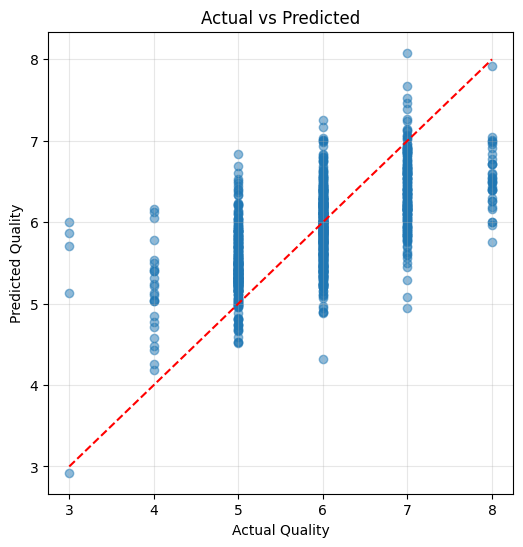

In [296]:
# ============================================
# 17. 산점도: 실제값 vs 예측값
# ============================================
plt.figure(figsize=(6, 6))
plt.scatter(actual_values, test_predictions, alpha=0.5)
plt.plot(
    [actual_values.min(), actual_values.max()],
    [actual_values.min(), actual_values.max()],
    'r--'
)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.show()